In [1]:
# Import libraries
import os
import pickle
import numpy as np
import pandas as pd
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
approach = "attention"

# Heatmap Fine-tuned


In [ ]:
mean_score_df:pd.DataFrame = pd.DataFrame()

# Open the layer
for layer in range(12):
    with open(f'/DNABERT/enhancer_scores/examples_scores_attention_1000_layer{layer}.p', 'rb') as f:
        results:dict = pickle.load(f)

    # Calculate mean score per sequence per head
    tmp_dict:dict = {}
    for head in results:
        tmp_list:list = []
        for i in range(len(results[head])):
          tmp_list.append(np.mean((results[head][i][0])))
        tmp_dict[head] = tmp_list

    # Merge layer scores
    tmp_df:pd.DataFrame = pd.DataFrame(tmp_dict)
    tmp_df.columns = [f'head{i}' for i in range(12)]
    tmp_df['layer'] = f'layer{layer}'
    mean_score_df = pd.concat([mean_score_df, tmp_df])

# Save the results as a CSV
mean_score_df.to_csv(f'/DNABERT/enhancer_results/mean_{approach}_scores.csv', index=False)

del(tmp_df, tmp_dict, tmp_list, results, head, layer, f, i)

In [ ]:
# Calculate mean score for each layer
tmp_mean_df = mean_score_df.groupby('layer').mean()

# Normalize the scores within each layer
tmp_mean_df = tmp_mean_df.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

# Sort layers
tmp_mean_df = tmp_mean_df.reindex(sorted(tmp_mean_df.index, key=lambda x: int(x[5:])))

# Plotting
plt.figure(1, figsize=(9, 6))
sns.set(color_codes=True)
sns.set(font_scale=0.9)
ax = sns.heatmap(tmp_mean_df, cmap='GnBu', cbar_kws={'label': 'Scale'})
ax.set(ylabel="Layers", xlabel="Heads")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
plt.savefig(f"/DNABERT/enhancer_results/dnabert_mean_attention_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Clean up to avoid conflicts in subsequent code
del(tmp_mean_df, ax)

# Heatmap - Pre-trained

In [3]:
mean_score_df:pd.DataFrame = pd.DataFrame()

# Open the layer
for layer in range(12):
    with open(f'/DNABERT/enhancer_scores_pretrained/examples_scores_attention_1000_layer{layer}.p', 'rb') as f:
        results:dict = pickle.load(f)

    # Calculate mean score per sequence per head
    tmp_dict:dict = {}
    for head in results:
        tmp_list:list = []
        for i in range(len(results[head])):
          tmp_list.append(np.mean((results[head][i][0])))
        tmp_dict[head] = tmp_list

    # Merge layer scores
    tmp_df:pd.DataFrame = pd.DataFrame(tmp_dict)
    tmp_df.columns = [f'head{i}' for i in range(12)]
    tmp_df['layer'] = f'layer{layer}'
    mean_score_df = pd.concat([mean_score_df, tmp_df])

# Save the results as a CSV
mean_score_df.to_csv(f'/DNABERT/enhancer_results_pretrained/mean_{approach}_scores_pretrained.csv', index=False)

del(tmp_df, tmp_dict, tmp_list, results, head, layer, f, i)

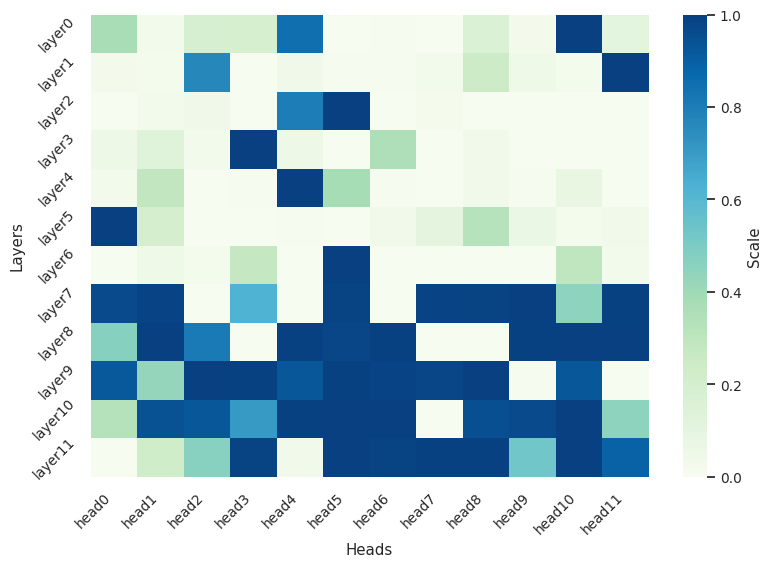

In [4]:
# Calculate mean score for each layer
tmp_mean_df = mean_score_df.groupby('layer').mean()

# Normalize the scores within each layer
tmp_mean_df = tmp_mean_df.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

# Sort layers
tmp_mean_df = tmp_mean_df.reindex(sorted(tmp_mean_df.index, key=lambda x: int(x[5:])))

# Plotting
plt.figure(1, figsize=(9, 6))
sns.set(color_codes=True)
sns.set(font_scale=0.9)
ax = sns.heatmap(tmp_mean_df, cmap='GnBu', cbar_kws={'label': 'Scale'})
ax.set(ylabel="Layers", xlabel="Heads")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
plt.savefig(f"/DNABERT/enhancer_results_pretrained/dnabert_pretrained_mean_attention_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Clean up to avoid conflicts in subsequent code
del(tmp_mean_df, ax)